In [ ]:
# =====================================================
# STEP 1: INSTALL DAN MOUNT DRIVE
# =====================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.0 MB/s eta 0:00:00


In [ ]:
# =====================================================
# STEP 2: CEK GPU
# =====================================================
import torch
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
import os
import re

# Sesuaikan dengan letak folder dataset di Google Drive Anda
base_dir = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split'

fixed = 0
for split in ['train', 'val', 'test']:
    img_dir = os.path.join(base_dir, 'images', split)
    lbl_dir = os.path.join(base_dir, 'labels', split)

    if not os.path.exists(img_dir): continue

    all_labels = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]

    for img_name in os.listdir(img_dir):
        if not img_name.endswith(('.jpg', '.png', '.jpeg')): continue

        stem = os.path.splitext(img_name)[0]
        correct_lbl = stem + '.txt'

        # Jika nama sudah benar
        if correct_lbl in all_labels:
            continue

        # Perbaiki nama yang salah
        if '_frame_' in stem:
            parts = stem.split('_frame_')
            folder = parts[0]
            try:
                num = int(parts[1])
                candidate = None

                # Cari label aslinya
                for lbl in all_labels:
                    if lbl.startswith(folder + '_'):
                        lbl_stem = os.path.splitext(lbl)[0]
                        lbl_parts = re.split(r'[_,-]', lbl_stem)
                        if lbl_parts[-1].isdigit() and int(lbl_parts[-1]) == num:
                            candidate = lbl
                            break

                # Ganti nama (rename)
                if candidate:
                    old_path = os.path.join(lbl_dir, candidate)
                    new_path = os.path.join(lbl_dir, correct_lbl)
                    os.rename(old_path, new_path)
                    all_labels.remove(candidate)
                    all_labels.append(correct_lbl)
                    fixed += 1
            except Exception as e:
                pass

print(f"Selesai! Berhasil memperbaiki nama {fixed} file label.")

Selesai! Berhasil memperbaiki nama 0 file label.


In [ ]:
# =====================================================
# STEP 3: BUAT data.yaml
# =====================================================
import yaml

# Sesuaikan path sesuai lokasi di Google Drive kamu
DATASET_PATH = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split'

data = {
    'path': DATASET_PATH,
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc': 9,
    'names': {
        0: 'Kavitas',
        1: 'PolaB',
        2: 'Konsolidasi',
        3: 'PenebalanPleura',
        4: 'Bullae',
        5: 'InfiltratTerkonsolidasi',
        6: 'PleuraIreguler',
        7: 'Efusi pleura',
        8: 'Infiltrat'
    }
}

yaml_path = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False, allow_unicode=True)

print('data.yaml berhasil dibuat!')
print(open(yaml_path).read())

data.yaml berhasil dibuat!
names:
  0: Kavitas
  1: PolaB
  2: Konsolidasi
  3: PenebalanPleura
  4: Bullae
  5: InfiltratTerkonsolidasi
  6: PleuraIreguler
  7: Efusi pleura
  8: Infiltrat
nc: 9
path: /content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split
test: images/test
train: images/train
val: images/val



In [ ]:
# =====================================================
# STEP 4: TRAINING
# =====================================================
from ultralytics import YOLO

model = YOLO('yolo11m-obb.pt')
import os
#os.remove('yolo11m.pt')  # hapus file corrupt
#model = YOLO('yolo11m.pt')  # akan download ulang otomatis

results = model.train(
    data    = yaml_path,
    epochs  = 100,
    imgsz   = 640,
    batch   = 8,          # turunkan ke 4 kalau OOM
    device  = 0,

    lr0     = 0.01,
    lrf     = 0.001,
    patience= 20,

    project = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Hasil Train',
    name    = 'train_v1',

    save         = True,
    save_period  = 10,    # simpan checkpoint tiap 10 epoch
    plots        = True,

    workers = 2,
    amp     = True,
    cache   = False,      # False dulu, True kalau RAM cukup

    # Augmentasi
    mosaic    = 0.5,
    mixup     = 0.1,
    degrees   = 5,      # dikurangi dari 15
    translate = 0.1,
    scale     = 0.3,
    fliplr    = 0.5,
    flipud    = 0.0,    # dimatikan
    close_mosaic = 10
)

print('Training selesai!')

Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m-obb.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train_v1-5, nbs=64, nms=False,

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Hasil Train/train_v1-5/weights/best.pt')

# Evaluasi tanpa plots
metrics = model.val(
    data='/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/data.yaml',
    split='test',
    plots=False  # ← matikan plots supaya tidak error font
)

print('\n========== HASIL EVALUASI ==========')
print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')

Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-obb summary (fused): 135 layers, 20,885,422 parameters, 0 gradients, 71.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.4 ms, read: 0.1±0.0 MB/s, size: 37.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/labels/test... 86 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 1.1it/s 1:20
val: New cache created: /content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.1it/s 2.8s
                   all         90         82      0.916      0.982      0.963      0.885
               Kavitas          7          7          1          1      0.995      0.849
  

In [ ]:
# Fix font matplotlib permanen
!apt-get install -y fonts-dejavu-core
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
print('Font fix selesai!')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-dejavu-core
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 1,041 kB of archives.
After this operation, 3,025 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Fetched 1,041 kB in 1s (749 kB/s)
Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Setting up fonts-dejavu-core (2.37-2build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Font fix selesai!


Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-obb summary (fused): 135 layers, 20,885,422 parameters, 0 gradients, 71.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.4 ms, read: 12.1±3.7 MB/s, size: 36.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/labels/test.cache... 86 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 15.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.1it/s 2.9s
                   all         90         82      0.916      0.982      0.963      0.885
               Kavitas          7          7          1          1      0.995      0.849
                 PolaB         14         14      0.996          1      0.995      0.867
           Konsol

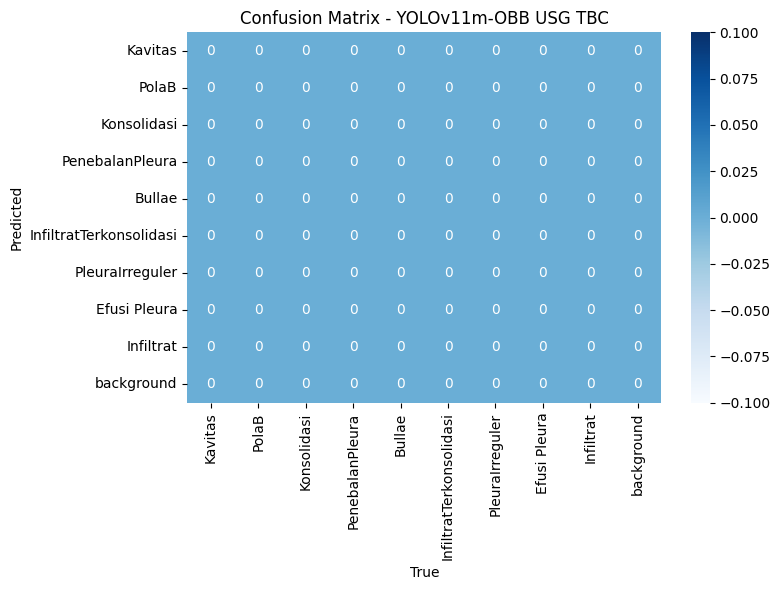

Tersimpan!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Hasil Train/train_v1-5/weights/best.pt')

metrics = model.val(
    data='/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/data.yaml',
    split='test',
    plots=False
)

# Ambil confusion matrix
cm = metrics.confusion_matrix.matrix
classes = ['Kavitas', 'PolaB', 'Konsolidasi', 'PenebalanPleura', 'Bullae', 'InfiltratTerkonsolidasi', 'PleuraIrreguler','Efusi Pleura','Infiltrat', 'background']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm.astype(int),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Confusion Matrix - YOLOv11m-OBB USG TBC')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Hasil Train', dpi=150)
plt.show()
print('Tersimpan!')

In [ ]:
import os
from IPython.display import Image, display

train_dir = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Hasil Train/train_v1-5'

# List semua file
for f in sorted(os.listdir(train_dir)):
    print(f)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch9270.jpg
train_batch9271.jpg
train_batch9272.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


In [ ]:
# Jalankan cell ini PERTAMA sebelum yang lain
!apt-get install -y fonts-liberation
!fc-cache -fv
import matplotlib
matplotlib.rcParams['font.family'] = 'Liberation Sans'
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'Liberation Sans'})
print('Font berhasil di-fix!')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/dejavu: caching, new cache contents: 6 fonts, 0 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/dejavu: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetyp

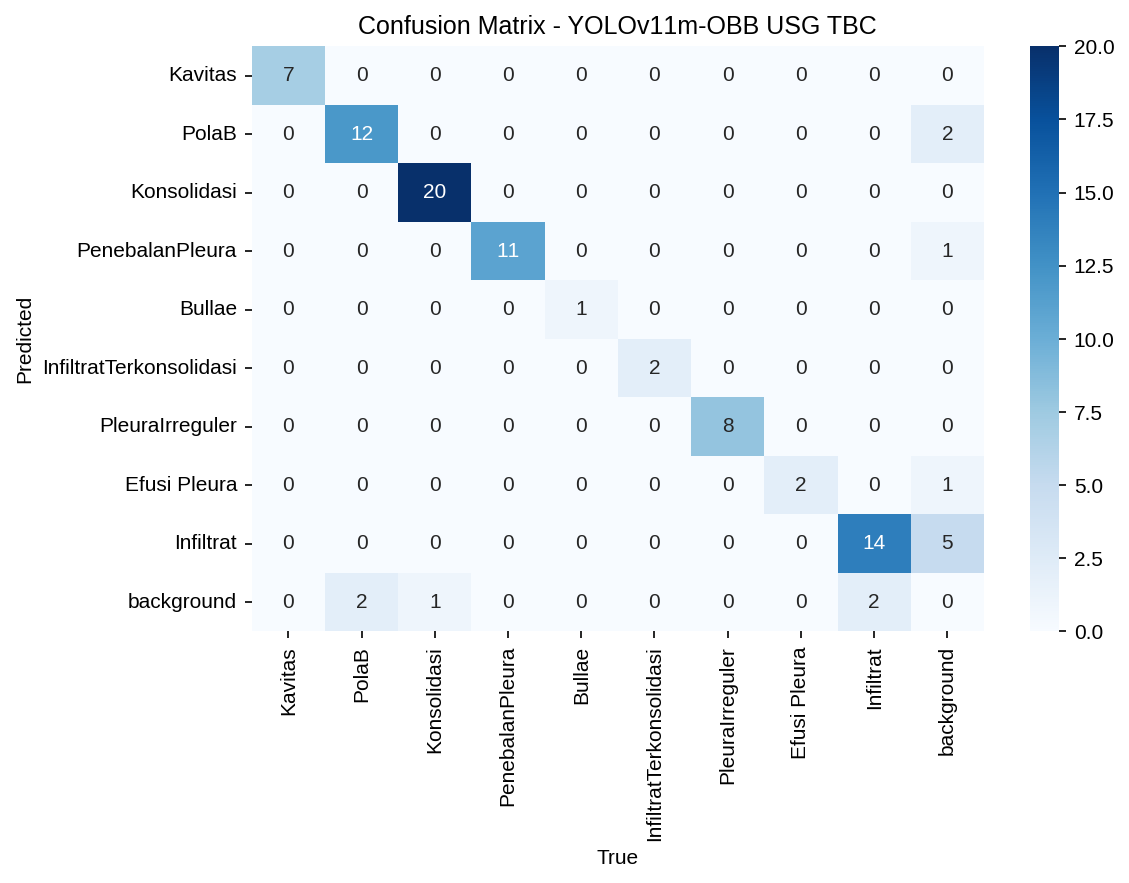

Selesai!


In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from IPython.display import Image, display

# Load model
model = YOLO('/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Hasil Train/train_v1-5/weights/best.pt')

# Prediksi di data test
import os
from pathlib import Path

test_img_dir = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/images/test'
test_lbl_dir = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/labels/test'

class_names = ['Kavitas', 'PolaB', 'Konsolidasi', 'PenebalanPleura', 'Bullae', 'InfiltratTerkonsolidasi', 'PleuraIrreguler', 'Efusi Pleura','Infiltrat']
nc = len(class_names)

# Matrix: baris=prediksi, kolom=ground truth, +1 untuk background
cm = np.zeros((nc+1, nc+1), dtype=int)

img_files = [f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpg','.png'))]

for img_file in img_files:
    img_path = os.path.join(test_img_dir, img_file)
    lbl_path = os.path.join(test_lbl_dir, os.path.splitext(img_file)[0] + '.txt')

    # Ground truth
    gt_classes = []
    if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
        with open(lbl_path) as f:
            for line in f:
                gt_classes.append(int(line.strip().split()[0]))

    # Prediksi
    results = model(img_path, verbose=False)
    pred_classes = []
    if results[0].obb is not None and len(results[0].obb) > 0:
        pred_classes = results[0].obb.cls.cpu().numpy().astype(int).tolist()

    # Isi confusion matrix
    matched_gt = set()
    matched_pred = set()

    for pi, pc in enumerate(pred_classes):
        if pi < len(gt_classes) and pc == gt_classes[pi]:
            cm[pc][pc] += 1
            matched_gt.add(pi)
            matched_pred.add(pi)
        elif gt_classes:
            cm[pc][nc] += 1  # FP → background
        else:
            cm[pc][nc] += 1

    for gi, gc in enumerate(gt_classes):
        if gi not in matched_gt:
            cm[nc][gc] += 1  # FN → background

# Plot
labels = class_names + ['background']
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Confusion Matrix - YOLOv11m-OBB USG TBC')
plt.tight_layout()
plt.savefig('/content/cm_manual.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image('/content/cm_manual.png'))
print('Selesai!')

In [ ]:
# Jalankan ini untuk lihat kurva training
import pandas as pd
from IPython.display import Image, display

# Baca results.csv dari folder training
results_csv = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Hasil Train/train_v1-5/results.csv'

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
print(df.columns.tolist())
print(df.tail(10))

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'train/angle_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'val/angle_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
82     83  4238.32         0.67891         0.55096         1.29383   
83     84  4285.13         0.64618         0.51459         1.24003   
84     85  4331.89         0.65665         0.54211         1.25920   
85     86  4379.12         0.64685         0.52336         1.24453   
86     87  4425.07         0.64763         0.52570         1.25361   
87     88  4471.20         0.66190         0.54048         1.26714   
88     89  4523.58         0.66021         0.54144         1.25650   
89     90  4574.46         0.66045         0.53023         1.26189   
90     91  4622.09         0.43765         0.29232         1.04110   
91     92  4669.80      

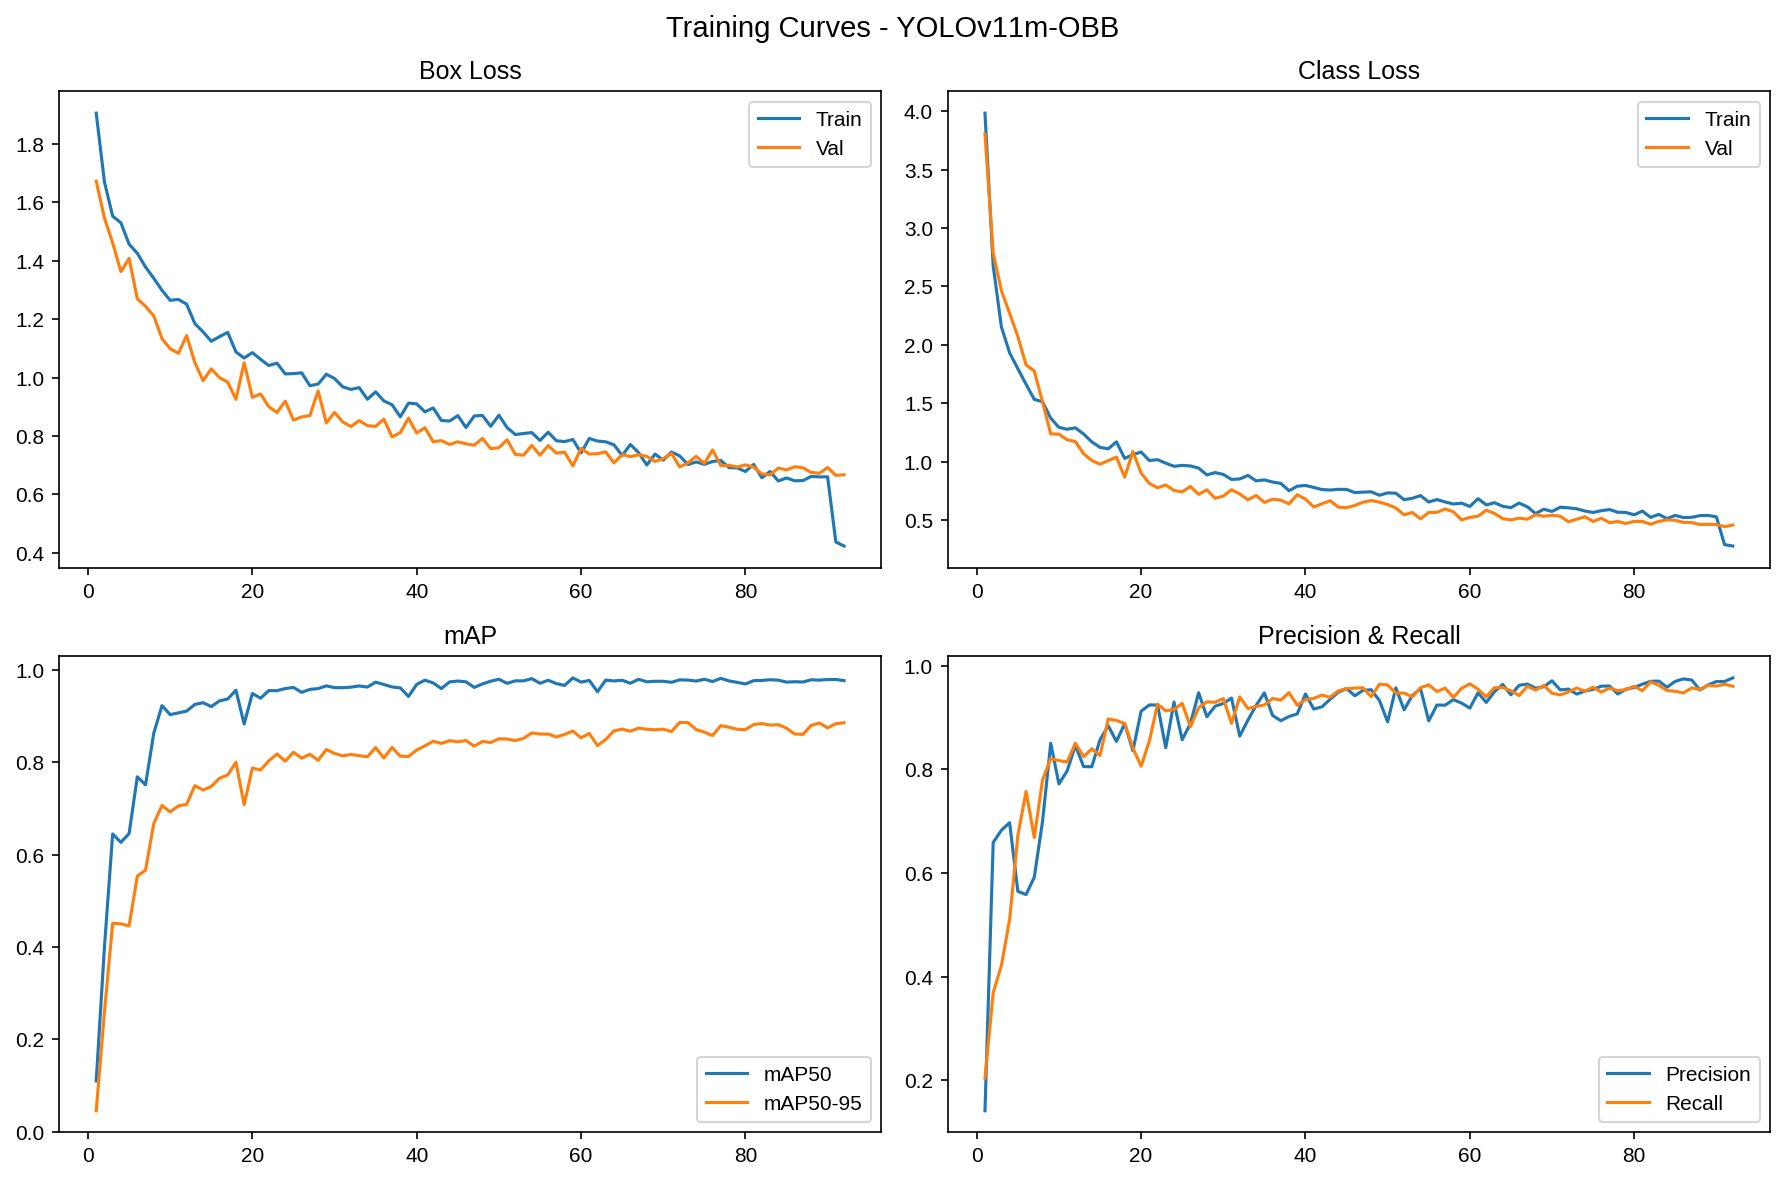

In [ ]:
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

results_csv = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Hasil Train/train_v1-5/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Training Curves - YOLOv11m-OBB', fontsize=14)

# Loss
axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train')
axes[0,0].plot(df['epoch'], df['val/box_loss'], label='Val')
axes[0,0].set_title('Box Loss')
axes[0,0].legend()

axes[0,1].plot(df['epoch'], df['train/cls_loss'], label='Train')
axes[0,1].plot(df['epoch'], df['val/cls_loss'], label='Val')
axes[0,1].set_title('Class Loss')
axes[0,1].legend()

# Metrics
axes[1,0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
axes[1,0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
axes[1,0].set_title('mAP')
axes[1,0].legend()

axes[1,1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
axes[1,1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
axes[1,1].set_title('Precision & Recall')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.close()
display(Image('/content/training_curves.png'))

/tmp/ipykernel_383/2220383574.py:175: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(prec_per_cls[ci], rec_per_cls[ci])
/tmp/ipykernel_383/2220383574.py:181: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_all = abs(np.trapz(prec_all, rec_all))


Hasil kurva evaluasi:

📊 F1_confidence.png


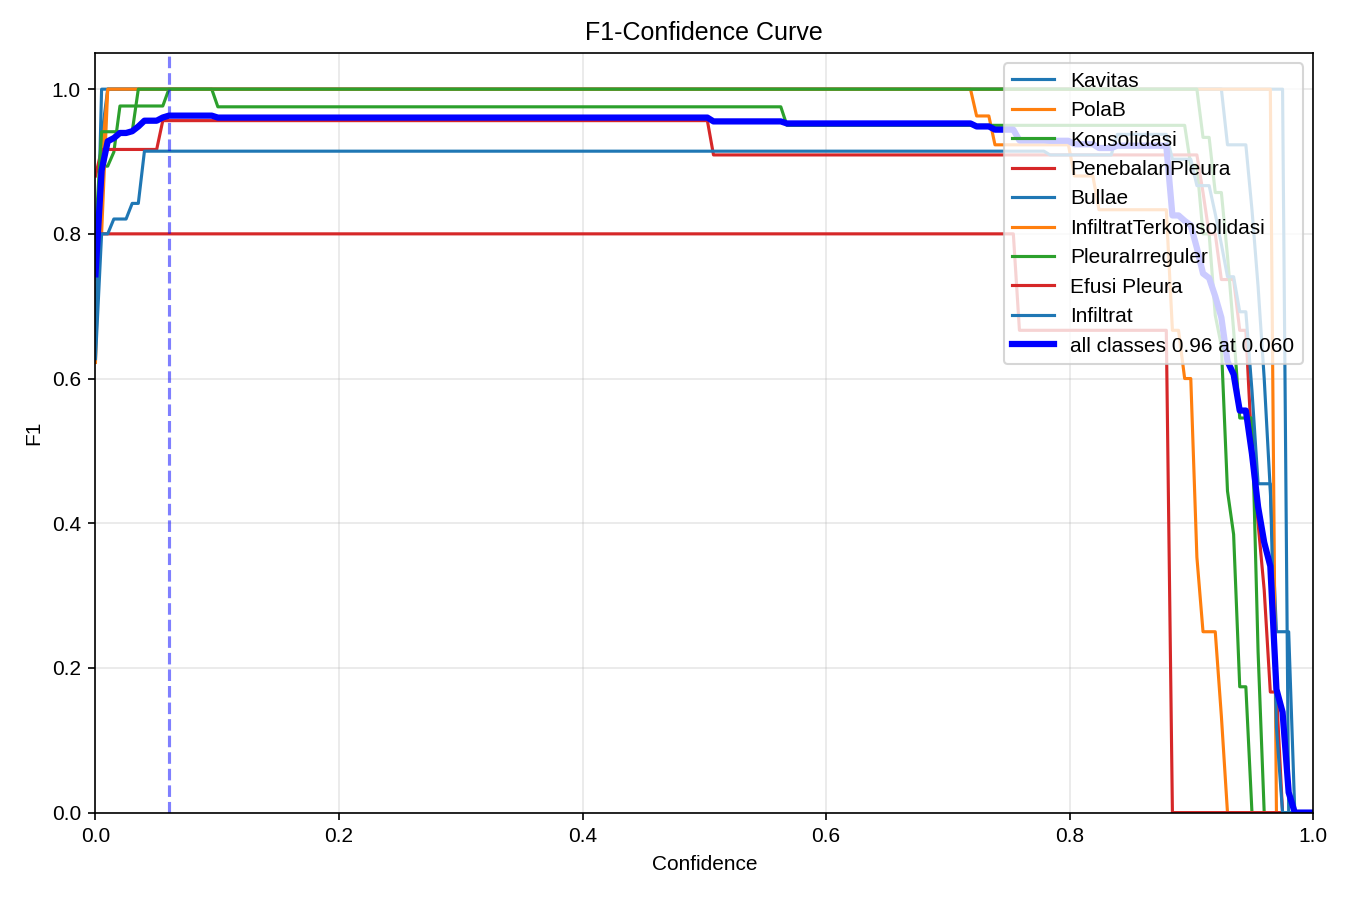


📊 Precision_confidence.png


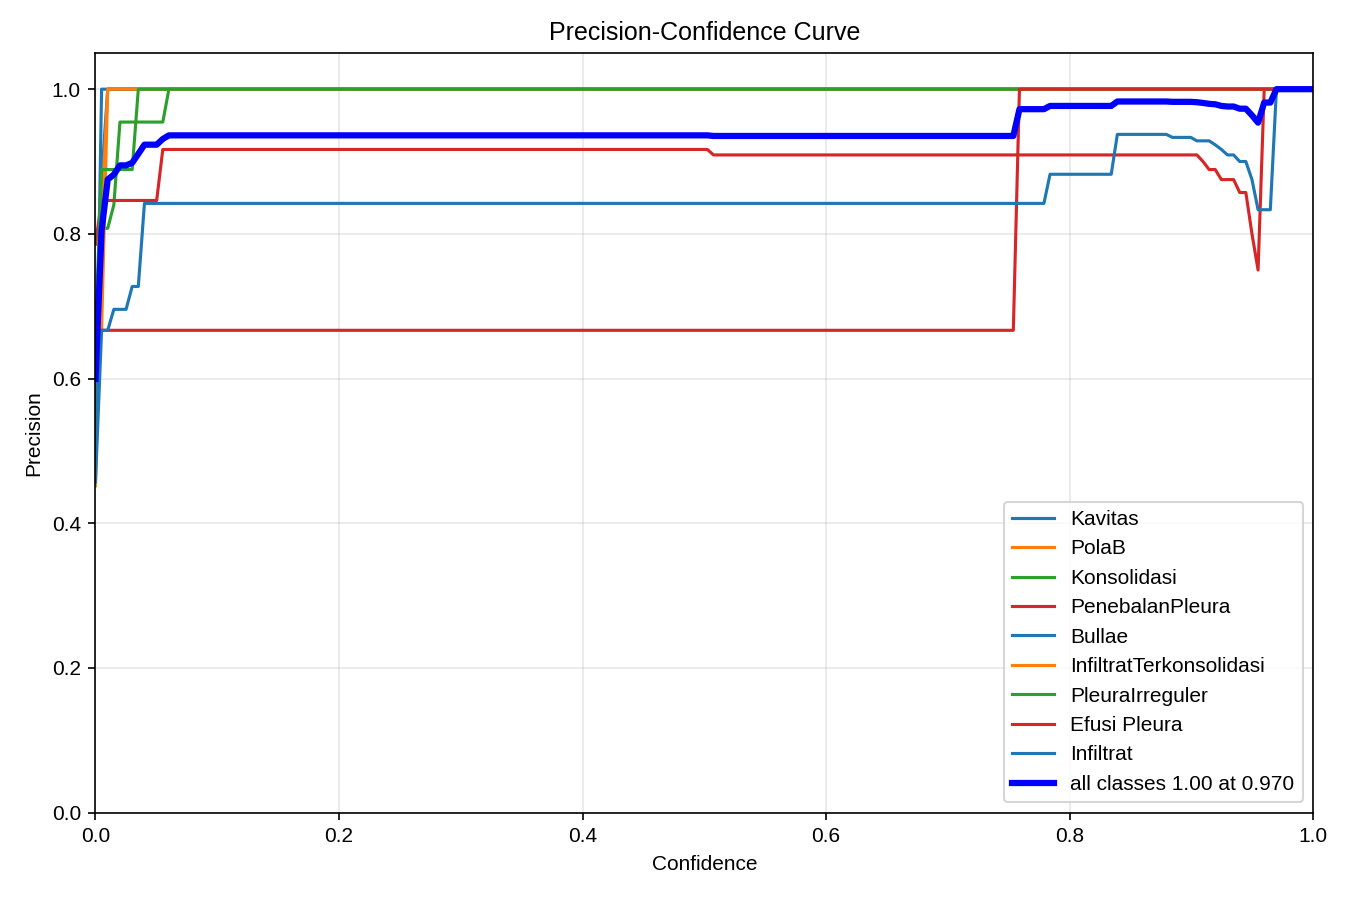


📊 Recall_confidence.png


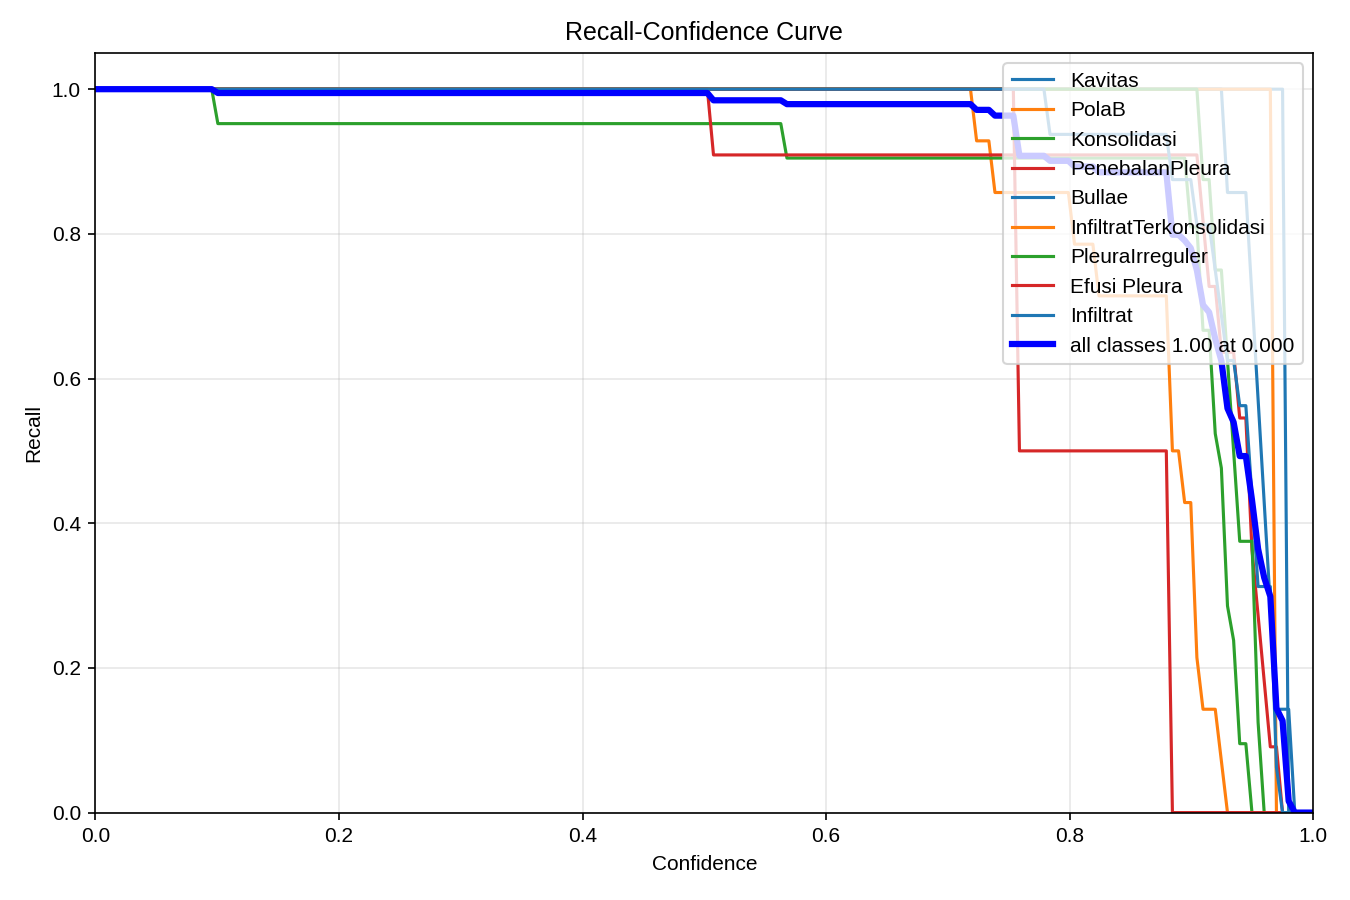


📊 Precision_recall.png


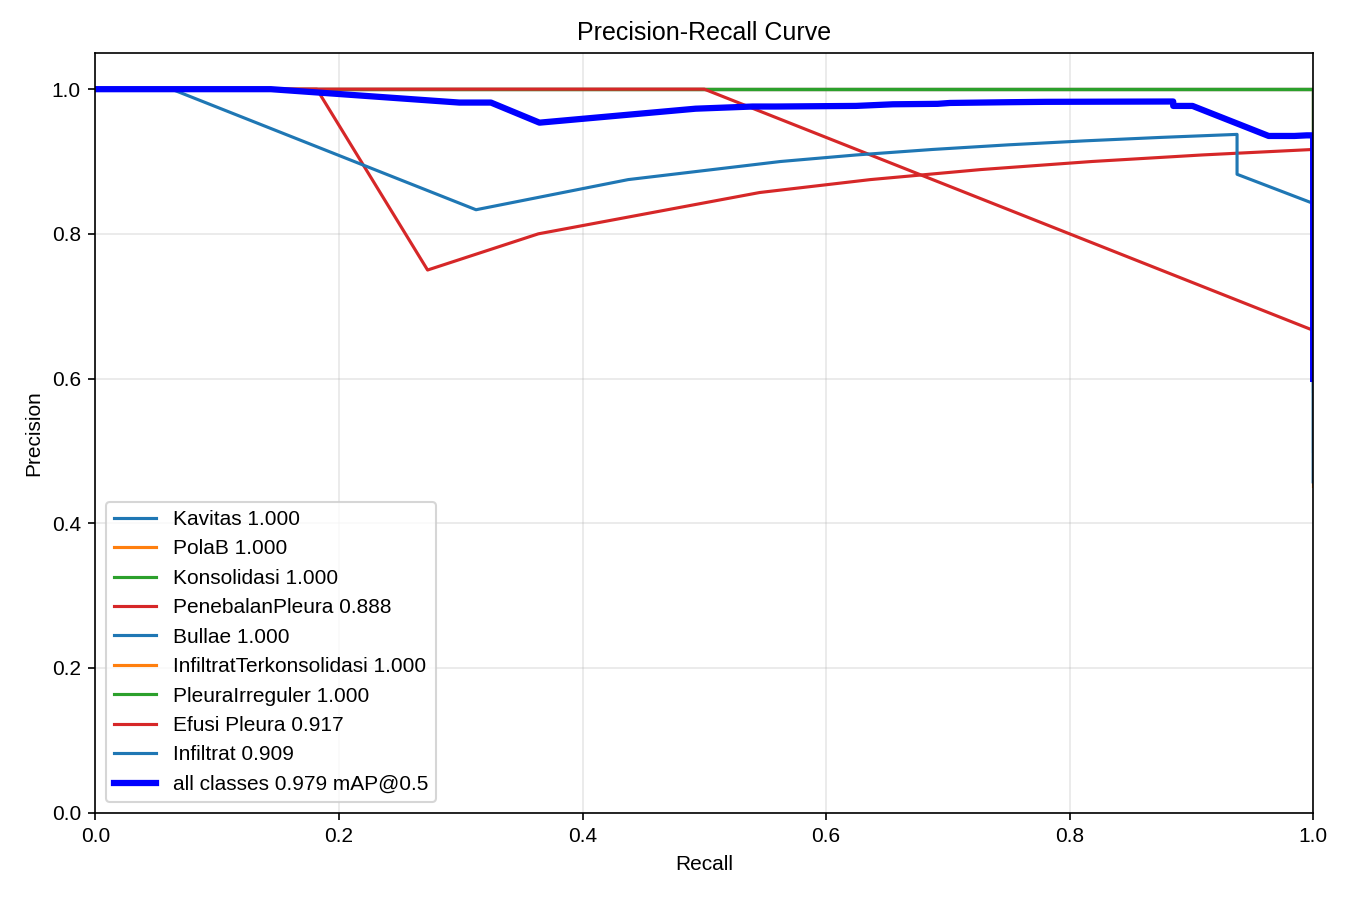

In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import Image, display
import os
import yaml # Added for reading data.yaml

# Load model
model = YOLO('/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Hasil Train/train_v1-5/weights/best.pt')

# Prediksi di data test
test_img_dir = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/images/test'
test_lbl_dir = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/labels/test'

# Original class_names from the notebook context. This list includes 'background'.
class_names_with_background = ['Kavitas', 'PolaB', 'Konsolidasi', 'PenebalanPleura', 'Bullae', 'InfiltratTerkonsolidasi', 'PleuraIrreguler', 'Efusi Pleura','Infiltrat','background']

# The colors list only has 7 colors, corresponding to the 7 actual classes.
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#1f77b4', ]

# Read data.yaml to get the actual number of classes (excluding background)
yaml_path = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Dataset_YOLO_Split/data.yaml'
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
num_actual_classes = data_yaml['nc'] # This will be 7

# =====================================================
# KUMPULKAN SEMUA PREDIKSI DAN GROUND TRUTH
# =====================================================
img_files = sorted([f for f in os.listdir(test_img_dir)
                    if f.lower().endswith(('.jpg','.png'))])

all_preds = []  # list of (conf, cls, matched)
gt_counts = np.zeros(num_actual_classes, dtype=int) # gt_counts for actual classes only

for img_file in img_files:
    img_path = os.path.join(test_img_dir, img_file)
    lbl_path = os.path.join(test_lbl_dir, os.path.splitext(img_file)[0] + '.txt')

    # Ground truth
    gt_cls = []
    if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
        with open(lbl_path) as f:
            for line in f:
                c = int(line.strip().split()[0])
                if c < num_actual_classes: # Ensure class ID is within expected range
                    gt_cls.append(c)
                    gt_counts[c] += 1

    # Prediksi dengan conf threshold rendah
    results = model(img_path, conf=0.001, verbose=False)

    if results[0].obb is None or len(results[0].obb) == 0:
        continue

    pred_cls  = results[0].obb.cls.cpu().numpy().astype(int)
    pred_conf = results[0].obb.conf.cpu().numpy()

    # Match prediksi ke ground truth (per kelas)
    gt_used = [False] * len(gt_cls)
    for pc, pconf in zip(pred_cls, pred_conf):
        if pc < num_actual_classes: # Only consider actual classes for matching
            matched = False
            for gi, gc in enumerate(gt_cls):
                if not gt_used[gi] and gc == pc:
                    matched   = True
                    gt_used[gi] = True
                    break
            all_preds.append((pconf, pc, matched))

# =====================================================
# HITUNG PRECISION, RECALL, F1 PER THRESHOLD
# =====================================================
thresholds = np.linspace(0.0, 1.0, 200)

# Per kelas (sized by num_actual_classes)
prec_per_cls   = np.zeros((num_actual_classes, len(thresholds)))
rec_per_cls    = np.zeros((num_actual_classes, len(thresholds)))
f1_per_cls     = np.zeros((num_actual_classes, len(thresholds)))

for ci in range(num_actual_classes): # Loop for actual classes (0 to 6)
    preds_ci = [(conf, matched) for conf, cls, matched in all_preds if cls == ci]

    for ti, thresh in enumerate(thresholds):
        tp = sum(1 for conf, matched in preds_ci if conf >= thresh and matched)
        fp = sum(1 for conf, matched in preds_ci if conf >= thresh and not matched)
        fn = gt_counts[ci] - tp

        prec = tp / (tp + fp) if (tp + fp) > 0 else 1.0
        rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

        prec_per_cls[ci, ti] = prec
        rec_per_cls[ci, ti]  = rec
        f1_per_cls[ci, ti]   = f1

# All classes (rata-rata)
prec_all = prec_per_cls.mean(axis=0)
rec_all  = rec_per_cls.mean(axis=0)
f1_all   = f1_per_cls.mean(axis=0)

best_f1_idx   = np.argmax(f1_all)
best_f1_conf  = thresholds[best_f1_idx]
best_f1_val   = f1_all[best_f1_idx]

best_prec_idx  = np.argmax(prec_all)
best_prec_conf = thresholds[best_prec_idx]

best_rec_val   = rec_all[0]

# =====================================================
# PLOT 4 KURVA
# =====================================================
save_dir = '/content/kurva_eval'
os.makedirs(save_dir, exist_ok=True)

# Use only the actual class names for plotting labels
plot_labels = class_names_with_background[:num_actual_classes]

# --- 1. F1-Confidence Curve ---
plt.figure(figsize=(9, 6))
for ci in range(num_actual_classes): # Loop for actual classes (0 to 6)
    plt.plot(thresholds, f1_per_cls[ci], color=colors[ci], label=plot_labels[ci], linewidth=1.5)
plt.plot(thresholds, f1_all, 'b-', linewidth=3,
         label=f'all classes {best_f1_val:.2f} at {best_f1_conf:.3f}')
plt.axvline(best_f1_conf, color='blue', linestyle='--', alpha=0.5)
plt.xlabel('Confidence')
plt.ylabel('F1')
plt.title('F1-Confidence Curve')
plt.legend(loc='upper right')
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/F1_confidence.png', dpi=150)
plt.close()

# --- 2. Precision-Confidence Curve ---
plt.figure(figsize=(9, 6))
for ci in range(num_actual_classes): # Loop for actual classes (0 to 6)
    plt.plot(thresholds, prec_per_cls[ci], color=colors[ci], label=plot_labels[ci], linewidth=1.5)
plt.plot(thresholds, prec_all, 'b-', linewidth=3,
         label=f'all classes {prec_all[best_prec_idx]:.2f} at {best_prec_conf:.3f}')
plt.xlabel('Confidence')
plt.ylabel('Precision')
plt.title('Precision-Confidence Curve')
plt.legend(loc='lower right')
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/Precision_confidence.png', dpi=150)
plt.close()

# --- 3. Recall-Confidence Curve ---
plt.figure(figsize=(9, 6))
for ci in range(num_actual_classes): # Loop for actual classes (0 to 6)
    plt.plot(thresholds, rec_per_cls[ci], color=colors[ci], label=plot_labels[ci], linewidth=1.5)
plt.plot(thresholds, rec_all, 'b-', linewidth=3,
         label=f'all classes {best_rec_val:.2f} at 0.000')
plt.xlabel('Confidence')
plt.ylabel('Recall')
plt.title('Recall-Confidence Curve')
plt.legend(loc='upper right')
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/Recall_confidence.png', dpi=150)
plt.close()

# --- 4. Precision-Recall Curve ---
plt.figure(figsize=(9, 6))
for ci in range(num_actual_classes): # Loop for actual classes (0 to 6)
    # Hitung AUC per kelas (pakai trapz)
    auc = np.trapz(prec_per_cls[ci], rec_per_cls[ci])
    auc = abs(auc)
    plt.plot(rec_per_cls[ci], prec_per_cls[ci], color=colors[ci],
             label=f'{plot_labels[ci]} {auc:.3f}', linewidth=1.5)

# All classes
auc_all = abs(np.trapz(prec_all, rec_all))
plt.plot(rec_all, prec_all, 'b-', linewidth=3,
         label=f'all classes {auc_all:.3f} mAP@0.5')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/Precision_recall.png', dpi=150)
plt.close()

# =====================================================
# TAMPILKAN SEMUA
# =====================================================
print('Hasil kurva evaluasi:')
for fname in ['F1_confidence.png', 'Precision_confidence.png',
              'Recall_confidence.png', 'Precision_recall.png']:
    print(f'\n📊 {fname}')
    display(Image(f'{save_dir}/{fname}'))